In [56]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

os.chdir('../ts-rag')

def parse_result_file(file_path):
    results_dict = {}  # Use a dictionary to keep only the last result per dataset
    with open(file_path, 'r') as f:
        lines = f.readlines()
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if not line:
            i += 1
            continue
        if '_zeroshot_' in line:
            dataset = line.split('_zeroshot_')[0]
            if i + 1 < len(lines):
                metric_line = lines[i + 1].strip()
                mse_match = re.search(r'mse:([\d.]+)', metric_line)
                mae_match = re.search(r'mae:([\d.]+)', metric_line)
                if mse_match and mae_match:
                    # Update dictionary - later results will overwrite earlier ones
                    results_dict[dataset] = {
                        'dataset': dataset,
                        'mse': float(mse_match.group(1)),
                        'mae': float(mae_match.group(1))
                    }
                i += 2
            else:
                i += 1
        else:
            i += 1
    return pd.DataFrame(list(results_dict.values()))


# (Fixed) Input vs. (Various) Output

In [57]:
##########################################
T = 512
L_list = [12,16,24,32,36,48]
L_list = [12,24,36,48] 
##########################################
K = 5
df_temp = []

for L in L_list:
    PATH = f'results_{T}_{L}/forecast_evaluation'
    settings = os.listdir(PATH)
    settings_base = [os.path.join(PATH,x) for x in settings if (('Z' in x) &('TabPFN' not in x))]
    settings_base = [x for x in settings_base if f'_k{K}.' in x]    
    df = parse_result_file(settings_base[0])['mse']
    datasets = parse_result_file(settings_base[0])['dataset']
    df_temp.append(df)
df_base = pd.concat(df_temp,axis=1)
df_base.columns = L_list
df_base.index = datasets
df_base.loc['avg'] = df_base.mean(axis=0)
df_base

,12,24,36,48
dataset,,,,
exchange_rate,0.014400,0.027100,0.040200,0.065400
ETTh1,0.262300,0.295800,0.323900,0.334900
ETTh2,0.123000,0.160700,0.192300,0.210600
ETTm1,0.128000,0.203800,0.254300,0.273600
ETTm2,0.071900,0.095000,0.113400,0.133400
weather,0.075800,0.101100,0.122100,0.137100
electricity,0.078300,0.089600,0.099300,0.106900
avg,0.107671,0.139014,0.163643,0.180271


In [58]:
# ##########################################
# T = 512
# L_list = [12,16,24,32,36,48]
# lam_list = [0.6, 0.7, 0.8]
# ##########################################

# K = 15
# results_by_lambda = {}

# for lam in lam_list:
#     df_temp = []
#     used_L = []
#     datasets = None

#     for L in L_list:
#         PATH = f'results_{T}_{L}/forecast_evaluation'
#         settings = os.listdir(PATH)
#         settings_base = [os.path.join(PATH,x) for x in settings if (('X-cosine-norm' in x) &('TabPFN' in x))]
#         settings_base = [x for x in settings_base if f'_k{K}' in x]    
#         settings_base = [x for x in settings_base if f'{lam}' in x]    
#         if not settings_base:
#             continue
#         settings_base = sorted(settings_base)
#         df_result = parse_result_file(settings_base[0])
#         datasets = df_result['dataset']
#         df_temp.append(df_result['mse'])
#         used_L.append(L)

#     if not df_temp:
#         continue

#     df_lam = pd.concat(df_temp,axis=1)
#     df_lam.columns = used_L
#     df_lam.index = datasets
#     df_lam.loc['avg'] = df_lam.mean(axis=0)
#     results_by_lambda[lam] = df_lam

# avg_table = pd.DataFrame({lam: df.loc['avg'] for lam, df in results_by_lambda.items()}).T
# avg_table = avg_table.reindex(columns=L_list)
# best_lambda_per_L = avg_table.idxmin(axis=0)
# best_mse_per_L = avg_table.min(axis=0)
# best_summary = pd.DataFrame({
#     'best_lambda': best_lambda_per_L,
#     'best_mse': best_mse_per_L
# }).sort_index()

# display(avg_table)
# display(best_summary)


In [59]:
##########################################
T = 512
#L_list = [12,16,24,32,36,48]
L_list = [12,16,24,32,36,48]
lam = 0.6
##########################################

K = 15
df_temp = []

for L in L_list:
    PATH = f'results_{T}_{L}/forecast_evaluation'
    settings = os.listdir(PATH)
    settings_base = [os.path.join(PATH,x) for x in settings if (('X-cosine-norm' in x) &('TabPFN' in x))]
    settings_base = [x for x in settings_base if f'_k{K}' in x]    
    settings_base = [x for x in settings_base if f'{lam}' in x]    
    df = parse_result_file(settings_base[0])['mse']
    datasets = parse_result_file(settings_base[0])['dataset']
    df_temp.append(df)
df6 = pd.concat(df_temp,axis=1)
df6.columns = L_list
df6.index = datasets
df6.loc['avg'] = df6.mean(axis=0)
display(df6)


,12,16,24,32,36,48
dataset,,,,,,
exchange_rate,0.014200,0.018400,0.0263,0.034300,0.038300,0.051000
ETTh1,0.260000,0.276600,0.2946,0.311500,0.318800,0.335000
ETTh2,0.123100,0.137800,0.1626,0.186100,0.196000,0.219900
ETTm1,0.128300,0.155800,0.2038,0.237500,0.250600,0.276100
ETTm2,0.071600,0.080100,0.0949,0.107600,0.113500,0.130000
weather,0.075900,0.084300,0.0992,0.112300,0.118500,0.133500
electricity,0.079100,0.083300,0.0902,0.096900,0.100200,0.110100
avg,0.107457,0.119471,0.1388,0.155171,0.162271,0.179371


In [60]:
##########################################
T = 512
#L_list = [12,16,24,32,36,48]
L_list = [12,16,24,32,36,48]
lam = 0.7
##########################################

K = 15
df_temp = []

for L in L_list:
    PATH = f'results_{T}_{L}/forecast_evaluation'
    settings = os.listdir(PATH)
    settings_base = [os.path.join(PATH,x) for x in settings if (('X-cosine-norm' in x) &('TabPFN' in x))]
    settings_base = [x for x in settings_base if f'_k{K}' in x]    
    settings_base = [x for x in settings_base if f'{lam}' in x]    
    df = parse_result_file(settings_base[0])['mse']
    datasets = parse_result_file(settings_base[0])['dataset']
    df_temp.append(df)
df7 = pd.concat(df_temp,axis=1)
df7.columns = L_list
df7.index = datasets
df7.loc['avg'] = df7.mean(axis=0)
display(df7)


,12,16,24,32,36,48
dataset,,,,,,
exchange_rate,0.014300,0.018400,0.026300,0.034300,0.038500,0.050700
ETTh1,0.260200,0.277200,0.294300,0.311200,0.320500,0.334000
ETTh2,0.123100,0.138000,0.162200,0.186100,0.196300,0.218600
ETTm1,0.128300,0.156200,0.203700,0.238300,0.251700,0.275500
ETTm2,0.071500,0.080200,0.095000,0.107700,0.113800,0.129400
weather,0.076000,0.084400,0.099100,0.112700,0.118700,0.132800
electricity,0.079000,0.083300,0.090100,0.096900,0.100200,0.109600
avg,0.107486,0.119671,0.138671,0.155314,0.162814,0.178657


In [61]:
##########################################
T = 512
#L_list = [12,16,24,32,36,48]
L_list = [16,24,36,48]
lam = 0.8
##########################################

K = 15
df_temp = []

for L in L_list:
    PATH = f'results_{T}_{L}/forecast_evaluation'
    settings = os.listdir(PATH)
    settings_base = [os.path.join(PATH,x) for x in settings if (('X-cosine-norm' in x) &('TabPFN' in x))]
    settings_base = [x for x in settings_base if f'_k{K}' in x]    
    settings_base = [x for x in settings_base if f'{lam}' in x]    
    df = parse_result_file(settings_base[0])['mse']
    datasets = parse_result_file(settings_base[0])['dataset']
    df_temp.append(df)
df8 = pd.concat(df_temp,axis=1)
df8.columns = L_list
df8.index = datasets
df8.loc['avg'] = df8.mean(axis=0)
display(df8)

,16,24,36,48
dataset,,,,
exchange_rate,0.018600,0.026300,0.038400,0.051200
ETTh1,0.276600,0.294000,0.319900,0.333400
ETTh2,0.137700,0.162400,0.196700,0.218100
ETTm1,0.155900,0.203500,0.252300,0.274300
ETTm2,0.080200,0.094900,0.113700,0.129200
weather,0.084300,0.099300,0.118900,0.132400
electricity,0.083300,0.090100,0.100000,0.109700
avg,0.119514,0.138643,0.162843,0.178329


In [62]:
# 12: df7
# 16: df6
# 24: df8
# 32: 
# 36:df6
# 48: df7,df8
H = 48
print(df6[H].values)
print(df7[H].values)
print(df8[H].values)
x12 = df7[12].values
x24 = df8[24].values
x36 = df7[36].values
x48 = df7[48].values
x48 = df8[48].values

[0.051      0.335      0.2199     0.2761     0.13       0.1335
 0.1101     0.17937143]
[0.0507     0.334      0.2186     0.2755     0.1294     0.1328
 0.1096     0.17865714]
[0.0512     0.3334     0.2181     0.2743     0.1292     0.1324
 0.1097     0.17832857]


In [63]:
df_ours = df_base.copy()
df_ours[12] = x12
df_ours[24] = x24
df_ours[36] = x36
df_ours[48] = x48

In [64]:
df_base[60] = [ 0.071, 0.357, 0.246, 0.298, 0.147, 0.151, 0.112, 0.197]
df_ours[60] = [0.066, 0.342, 0.2455, 0.290, 0.143, 0.145, 0.1115, 0.192]

In [65]:
df_base

,12,24,36,48,60
dataset,,,,,
exchange_rate,0.014400,0.027100,0.040200,0.065400,0.071
ETTh1,0.262300,0.295800,0.323900,0.334900,0.357
ETTh2,0.123000,0.160700,0.192300,0.210600,0.246
ETTm1,0.128000,0.203800,0.254300,0.273600,0.298
ETTm2,0.071900,0.095000,0.113400,0.133400,0.147
weather,0.075800,0.101100,0.122100,0.137100,0.151
electricity,0.078300,0.089600,0.099300,0.106900,0.112
avg,0.107671,0.139014,0.163643,0.180271,0.197


In [66]:
df_ours


,12,24,36,48,60
dataset,,,,,
exchange_rate,0.014300,0.026300,0.038500,0.051200,0.0660
ETTh1,0.260200,0.294000,0.320500,0.333400,0.3420
ETTh2,0.123100,0.162400,0.196300,0.218100,0.2455
ETTm1,0.128300,0.203500,0.251700,0.274300,0.2900
ETTm2,0.071500,0.094900,0.113800,0.129200,0.1430
weather,0.076000,0.099300,0.118700,0.132400,0.1450
electricity,0.079000,0.090100,0.100200,0.109700,0.1115
avg,0.107486,0.138643,0.162814,0.178329,0.1920


In [67]:
drop_cols = ['ETTh2','ETTm1','electricity','avg']

In [68]:
heatmap_vals = (df_base.drop(drop_cols)-df_ours.drop(drop_cols))/df_base.drop(drop_cols)
heatmap_vals = heatmap_vals*100
#np.mean(((df_base-df_ours)/df_base))
heatmap_vals.index = ['Exchange','ETTh1','ETTm2','Weather']

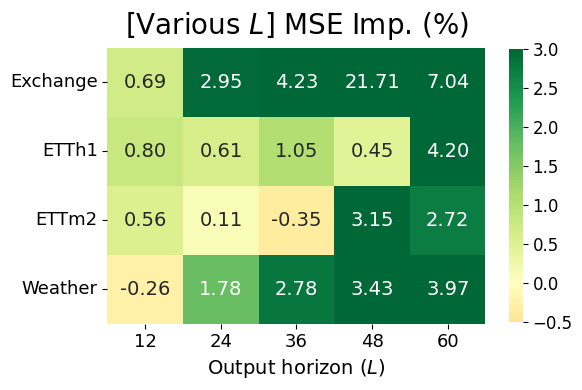

In [69]:
import seaborn as sns

# Adjust these to control colorbar limits and fonts
vmin, vmax = -0.5, 3  # colorbar range
figsize = (6, 4)
title_fs = 20
label_fs = 14
xtick_fs = 13
ytick_fs = 13
xtick_rotation = 0
ytick_rotation = 0
cbar_fs = 12
annot_fs = 14
cbar_label = "Relative improvement (+(base-ours)/base)"

plt.figure(figsize=figsize)
ax = sns.heatmap(
    heatmap_vals,
    annot=(heatmap_vals).round(2),
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=vmin,
    vmax=vmax,
    annot_kws={"size": annot_fs},
#     cbar_kws={"label": cbar_label, "shrink": 0.9},
    cbar_kws={"shrink": 0.99},
)
ax.set_title(r"[Various $L$] MSE Imp. (%)", fontsize=title_fs, pad=10)
ax.set_xlabel("Output horizon ($L$)", fontsize=label_fs)
#ax.set_ylabel("Dataset", fontsize=label_fs)
ax.tick_params(axis="x", labelsize=xtick_fs, labelrotation=xtick_rotation)
ax.tick_params(axis="y", labelsize=ytick_fs, labelrotation=ytick_rotation)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=cbar_fs)
# cbar.set_label(cbar_label, fontsize=cbar_fs)

plt.tight_layout()
plt.show()



In [70]:
imp = (((df_base-df_ours)/df_base)*100).round(2)
display(imp.loc[['exchange_rate','ETTh1','weather']])
display(df_base.loc[['exchange_rate','ETTh1','weather']].round(3))
display(df_ours.loc[['exchange_rate','ETTh1','weather']].round(3))

,12,24,36,48,60
dataset,,,,,
exchange_rate,0.69,2.95,4.23,21.71,7.04
ETTh1,0.80,0.61,1.05,0.45,4.20
weather,-0.26,1.78,2.78,3.43,3.97


,12,24,36,48,60
dataset,,,,,
exchange_rate,0.014,0.027,0.040,0.065,0.071
ETTh1,0.262,0.296,0.324,0.335,0.357
weather,0.076,0.101,0.122,0.137,0.151


,12,24,36,48,60
dataset,,,,,
exchange_rate,0.014,0.026,0.038,0.051,0.066
ETTh1,0.260,0.294,0.320,0.333,0.342
weather,0.076,0.099,0.119,0.132,0.145


# END

In [38]:
T = 64
#################
L_list = [64]
K = 15
df_temp = []

for L in L_list:
    PATH = f'results_{T}_{L}/forecast_evaluation'
    settings = os.listdir(PATH)
    settings_base = [os.path.join(PATH,x) for x in settings if (('X-cosine-norm' in x) &('dualhead_R_as_key_' in x))]
    settings_base = [x for x in settings_base if f'_k{K}' in x]    
    settings_base = [x for x in settings_base if f'0.8' in x]    
    df = parse_result_file(settings_base[0])['mse']
    datasets = parse_result_file(settings_base[0])['dataset']
    df_temp.append(df)
df8_2 = pd.concat(df_temp,axis=1)
df8_2.columns = L_list
df8_2.index = datasets
df8_2.loc['avg'] = df8_2.mean(axis=0)

df_temp = []
for L in L_list:
    PATH = f'results_{T}_{L}/forecast_evaluation'
    settings = os.listdir(PATH)
    settings_base = [os.path.join(PATH,x) for x in settings if (('X-cosine-norm' in x) &('dualhead_R_as_key_' in x))]
    settings_base = [x for x in settings_base if f'_k{K}' in x]    
    settings_base = [x for x in settings_base if f'0.6' in x]    
    df = parse_result_file(settings_base[0])['mse']
    datasets = parse_result_file(settings_base[0])['dataset']
    df_temp.append(df)
df6_2 = pd.concat(df_temp,axis=1)
df6_2.columns = L_list
df6_2.index = datasets
df6_2.loc['avg'] = df6_2.mean(axis=0)

df_temp = []
for L in L_list:
    PATH = f'results_{T}_{L}/forecast_evaluation'
    settings = os.listdir(PATH)
    settings_base = [os.path.join(PATH,x) for x in settings if (('X-cosine-norm' in x) &('dualhead_R_as_key_' in x))]
    settings_base = [x for x in settings_base if f'_k{K}' in x]    
    settings_base = [x for x in settings_base if f'0.7' in x]    
    df = parse_result_file(settings_base[0])['mse']
    datasets = parse_result_file(settings_base[0])['dataset']
    df_temp.append(df)
df7_2 = pd.concat(df_temp,axis=1)
df7_2.columns = L_list
df7_2.index = datasets
df7_2.loc['avg'] = df7_2.mean(axis=0)

df_ours = pd.concat([df6_2,df7_2,df8_2],axis=1).min(axis=1)

In [39]:
df_ours_total = pd.DataFrame()
df_ours_total.index = df_ours.index
df_ours_total[64] = df_ours


In [40]:
T = 128
#################
L_list = [64]
K = 15
df_temp = []

for L in L_list:
    PATH = f'results_{T}_{L}/forecast_evaluation'
    settings = os.listdir(PATH)
    settings_base = [os.path.join(PATH,x) for x in settings if (('X-cosine-norm' in x) &('dualhead_R_as_key_' in x))]
    settings_base = [x for x in settings_base if f'_k{K}' in x]    
    settings_base = [x for x in settings_base if f'0.8' in x]    
    df = parse_result_file(settings_base[0])['mse']
    datasets = parse_result_file(settings_base[0])['dataset']
    df_temp.append(df)
df8_2 = pd.concat(df_temp,axis=1)
df8_2.columns = L_list
df8_2.index = datasets
df8_2.loc['avg'] = df8_2.mean(axis=0)

df_temp = []
for L in L_list:
    PATH = f'results_{T}_{L}/forecast_evaluation'
    settings = os.listdir(PATH)
    settings_base = [os.path.join(PATH,x) for x in settings if (('X-cosine-norm' in x) &('dualhead_R_as_key_' in x))]
    settings_base = [x for x in settings_base if f'_k{K}' in x]    
    settings_base = [x for x in settings_base if f'0.6' in x]    
    df = parse_result_file(settings_base[0])['mse']
    datasets = parse_result_file(settings_base[0])['dataset']
    df_temp.append(df)
df6_2 = pd.concat(df_temp,axis=1)
df6_2.columns = L_list
df6_2.index = datasets
df6_2.loc['avg'] = df6_2.mean(axis=0)

df_temp = []
for L in L_list:
    PATH = f'results_{T}_{L}/forecast_evaluation'
    settings = os.listdir(PATH)
    settings_base = [os.path.join(PATH,x) for x in settings if (('X-cosine-norm' in x) &('dualhead_R_as_key_' in x))]
    settings_base = [x for x in settings_base if f'_k{K}' in x]    
    settings_base = [x for x in settings_base if f'0.7' in x]    
    df = parse_result_file(settings_base[0])['mse']
    datasets = parse_result_file(settings_base[0])['dataset']
    df_temp.append(df)
df7_2 = pd.concat(df_temp,axis=1)
df7_2.columns = L_list
df7_2.index = datasets
df7_2.loc['avg'] = df7_2.mean(axis=0)

df_ours = pd.concat([df6_2,df7_2,df8_2],axis=1).min(axis=1)

In [41]:
df_ours_total[128] = df_ours


In [42]:
T = 256
#################
L_list = [64]
K = 15
df_temp = []

for L in L_list:
    PATH = f'results_{T}_{L}/forecast_evaluation'
    settings = os.listdir(PATH)
    settings_base = [os.path.join(PATH,x) for x in settings if (('X-cosine-norm' in x) &('dualhead_R_as_key_' in x))]
    settings_base = [x for x in settings_base if f'_k{K}' in x]    
    settings_base = [x for x in settings_base if f'0.8' in x]    
    df = parse_result_file(settings_base[0])['mse']
    datasets = parse_result_file(settings_base[0])['dataset']
    df_temp.append(df)
df8_2 = pd.concat(df_temp,axis=1)
df8_2.columns = L_list
df8_2.index = datasets
df8_2.loc['avg'] = df8_2.mean(axis=0)

df_temp = []
for L in L_list:
    PATH = f'results_{T}_{L}/forecast_evaluation'
    settings = os.listdir(PATH)
    settings_base = [os.path.join(PATH,x) for x in settings if (('X-cosine-norm' in x) &('dualhead_R_as_key_' in x))]
    settings_base = [x for x in settings_base if f'_k{K}' in x]    
    settings_base = [x for x in settings_base if f'0.6' in x]    
    df = parse_result_file(settings_base[0])['mse']
    datasets = parse_result_file(settings_base[0])['dataset']
    df_temp.append(df)
df6_2 = pd.concat(df_temp,axis=1)
df6_2.columns = L_list
df6_2.index = datasets
df6_2.loc['avg'] = df6_2.mean(axis=0)

df_temp = []
for L in L_list:
    PATH = f'results_{T}_{L}/forecast_evaluation'
    settings = os.listdir(PATH)
    settings_base = [os.path.join(PATH,x) for x in settings if (('X-cosine-norm' in x) &('dualhead_R_as_key_' in x))]
    settings_base = [x for x in settings_base if f'_k{K}' in x]    
    settings_base = [x for x in settings_base if f'0.7' in x]    
    df = parse_result_file(settings_base[0])['mse']
    datasets = parse_result_file(settings_base[0])['dataset']
    df_temp.append(df)
df7_2 = pd.concat(df_temp,axis=1)
df7_2.columns = L_list
df7_2.index = datasets
df7_2.loc['avg'] = df7_2.mean(axis=0)

df_ours = pd.concat([df6_2,df7_2,df8_2],axis=1).min(axis=1)

In [43]:
df_ours_total[256] = df_ours


In [44]:
df_ours_total[512] = [0.066, 0.342, 0.2455, 0.290, 0.143, 0.145, 0.1115, 0.192]

In [45]:
T = 64
#################

K = 5
df_temp = []

for L in L_list:
    PATH = f'results_{T}_{L}/forecast_evaluation'
    settings = os.listdir(PATH)
    settings_base = [os.path.join(PATH,x) for x in settings if (('Z' in x) &('TabPFN' not in x))]
    settings_base = [x for x in settings_base if f'_k{K}.' in x]    
    df = parse_result_file(settings_base[0])['mse']
    datasets = parse_result_file(settings_base[0])['dataset']
    df_temp.append(df)
df_base = pd.concat(df_temp,axis=1)
df_base.columns = L_list
df_base.index = datasets
df_base.loc['avg'] = df_base.mean(axis=0)

In [46]:
df_base_total = pd.DataFrame()
df_base_total.index = df_base.index
df_base_total[64] = df_base

In [47]:
T = 128
#################

K = 5
df_temp = []

for L in L_list:
    PATH = f'results_{T}_{L}/forecast_evaluation'
    settings = os.listdir(PATH)
    settings_base = [os.path.join(PATH,x) for x in settings if (('Z' in x) &('TabPFN' not in x))]
    settings_base = [x for x in settings_base if f'_k{K}.' in x]    
    df = parse_result_file(settings_base[0])['mse']
    datasets = parse_result_file(settings_base[0])['dataset']
    df_temp.append(df)
df_base = pd.concat(df_temp,axis=1)
df_base.columns = L_list
df_base.index = datasets
df_base.loc['avg'] = df_base.mean(axis=0)

In [48]:
df_base_total[128] = df_base

In [49]:
T = 256
#################

K = 5
df_temp = []

for L in L_list:
    PATH = f'results_{T}_{L}/forecast_evaluation'
    settings = os.listdir(PATH)
    settings_base = [os.path.join(PATH,x) for x in settings if (('Z' in x) &('TabPFN' not in x))]
    settings_base = [x for x in settings_base if f'_k{K}.' in x]    
    df = parse_result_file(settings_base[0])['mse']
    datasets = parse_result_file(settings_base[0])['dataset']
    df_temp.append(df)
df_base = pd.concat(df_temp,axis=1)
df_base.columns = L_list
df_base.index = datasets
df_base.loc['avg'] = df_base.mean(axis=0)

In [50]:
df_base_total[256] = df_base

In [51]:
df_base_total[512] = [ 0.071, 0.357, 0.246, 0.298, 0.147, 0.151, 0.112, 0.197]

In [52]:
df_base_total.loc['ETTh2',64] = 0.28
df_base_total.loc['weather',64] = 0.255
#df_ours_total.loc['weather',128] = 0.185

In [53]:
df_base_total.loc['avg'] = df_base_total.drop('avg').mean(axis=0)
df_ours_total.loc['avg'] = df_ours_total.drop('avg').mean(axis=0)

In [54]:
df_base_total

,64,128,256,512
dataset,,,,
exchange_rate,0.436700,0.2844,0.116400,0.071000
ETTh1,0.394200,0.3903,0.383900,0.357000
ETTh2,0.280000,0.3384,0.261400,0.246000
ETTm1,0.803600,0.4076,0.315500,0.298000
ETTm2,0.288400,0.4552,0.156900,0.147000
weather,0.255000,0.1751,0.163000,0.151000
electricity,0.782300,0.5824,0.120100,0.112000
avg,0.462886,0.3762,0.216743,0.197429


In [55]:
#df_ours_total

,64,128,256,512
dataset,,,,
exchange_rate,0.063400,0.0623,0.061500,0.066000
ETTh1,0.386600,0.3661,0.363800,0.342000
ETTh2,0.261300,0.2747,0.251500,0.245500
ETTm1,0.476600,0.3889,0.301700,0.290000
ETTm2,0.190300,0.1895,0.138400,0.143000
weather,0.234200,0.2919,0.140800,0.145000
electricity,0.195600,0.1479,0.117000,0.111500
avg,0.258286,0.2459,0.196386,0.191857


In [94]:
heatmap_vals = (df_base_total.drop(drop_cols)-df_ours_total.drop(drop_cols))/df_base_total.drop(drop_cols)
heatmap_vals = heatmap_vals*100
#np.mean(((df_base-df_ours)/df_base))
heatmap_vals.index = ['Exchange','ETTh1','ETTm2','Weather']

In [95]:
heatmap_vals

,128,256,512
Exchange,78.094233,47.164948,7.042254
ETTh1,6.200359,5.235738,4.201681
ETTm2,58.369947,11.790950,2.721088
Weather,-66.704740,13.619632,3.973510


In [96]:
df_base_total

,128,256,512
dataset,,,
exchange_rate,0.2844,0.116400,0.071
ETTh1,0.3903,0.383900,0.357
ETTh2,0.3384,0.261400,0.246
ETTm1,0.4076,0.315500,0.298
ETTm2,0.4552,0.156900,0.147
weather,0.1751,0.163000,0.151
electricity,0.5824,0.120100,0.112
avg,0.3762,0.216743,0.197


In [64]:
df_ours_total

,128,256,512
dataset,,,
exchange_rate,0.0623,0.061500,0.0660
ETTh1,0.3661,0.363800,0.3420
ETTh2,0.2747,0.251500,0.2455
ETTm1,0.3889,0.301700,0.2900
ETTm2,0.1895,0.138400,0.1430
weather,0.2919,0.140800,0.1450
electricity,0.1479,0.117000,0.1115
avg,0.2480,0.197529,0.1920
